In [1]:
import prism
from pathlib import Path
from imagematerials.factory import ModelFactory, Sector
from imagematerials.maintenance import Maintenance, MaintenanceLinear

from imagematerials.model import (
    GenericMaterials,
    GenericStocks
)
import warnings
from imagematerials.preprocessing import get_preprocessing_data

In [2]:
base_dir = Path("..", "..", "image-materials", "data", "raw")
vhc_sector = get_preprocessing_data("vehicles", base_dir, cache = "vhc_sector2.nc")

circular_economy_scenario_dirs = {
        "slow": base_dir / 'circular_economy_scenarios' / 'slow'
    }
climate_policy_scenario_dir = base_dir / 'SSP2'

vhc_sector_slow = get_preprocessing_data("vehicles", base_dir, climate_policy_scenario_dir, circular_economy_scenario_dirs, cache = "vhc_sector_slow2.nc")


In [3]:
# Define simulation parameters
time_start = 1900
complete_timeline = prism.Timeline(time_start, 2110, 1)
simulation_timeline = prism.Timeline(1900, 2110, 1)

scenario_list = {
    'standard_linear': {
        'label': 'Standard Lifetimes & Linear Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'linear'
    },
    'standard_constant': {
        'label': 'Standard Lifetimes & Regular Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'constant'
    },
    'slow_constant': {
        'label': 'Slow Lifetimes & Regular Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'constant'
    },
    'slow_linear': {
        'label': 'Slow Lifetimes & Linear Maintenance',
        'circular_scen': 'slow',
        'maintenance_scen': 'linear'
    }
}


In [4]:
all_output = {}

for scen_id, scenario_config in scenario_list.items():   
    print(f"\n=== Running Scenario: {scen_id} ===")
    
    # Select the appropriate sector data based on circular economy scenario
    if scenario_config['circular_scen'] == 'standard':
        sector_data = vhc_sector
        print("Using standard sector data")
    elif scenario_config['circular_scen'] == 'slow':
        sector_data = vhc_sector_slow
        print("Using slow circular economy sector data")

    sector_data.all_data["cap_at_lifetime"]=False
    
    # Create factory with appropriate sector data
    factory = ModelFactory(
        sector_data, complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials)
    
    # Add the appropriate maintenance model based on maintenance scenario
    if scenario_config['maintenance_scen'] == 'constant':
        factory = factory.add(Maintenance)
        print("Using constant maintenance model")
    elif scenario_config['maintenance_scen'] == 'linear':
        # Pass vehicle_lifetimes as an explicit parameter to MaintenanceLinear
        factory = factory.add(MaintenanceLinear)
        print("Using linear maintenance model with explicit vehicle lifetimes")
    
    # Finish model creation
    model = factory.finish()
    
    # Run simulation
    
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)
    
    # Store results
    all_output[scen_id] = {
        'model': model,
        'inflow_maintenance': model.inflow_maintenance.to_array(),
        'circular_scenario': scenario_config['circular_scen'],
        'maintenance_scenario': scenario_config['maintenance_scen'],
        'label': scenario_config['label']
    }
    
    print(f"✓ Completed: {scen_id}")

print(f"\n=== All {len(all_output)} scenarios completed successfully ===")
print("Available scenarios:", list(all_output.keys()))



=== Running Scenario: standard_linear ===
Using standard sector data
Initialized MaintenanceLinear with 47 maintenance types
Using linear maintenance model with explicit vehicle lifetimes


KeyError: "not all values found in index 'Time'. Try setting the `method` keyword argument (example: method='nearest')."


Processing scenario: standard_linear
maintenance - Data shape: (201, 14)
maintenance - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']
production - Data shape: (201, 14)
production - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']

Processing scenario: standard_constant


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


maintenance - Data shape: (201, 14)
maintenance - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']
production - Data shape: (201, 14)
production - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']

Processing scenario: slow_constant
maintenance - Data shape: (201, 14)
maintenance - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']
production - Data shape: (201, 14)
production - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']

Processing scenario: slow_linear


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


maintenance - Data shape: (201, 14)
maintenance - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']
production - Data shape: (201, 14)
production - Data columns: ['Aluminium', 'Co', 'Cu', 'Glass', 'Li', 'Mn', 'Nd', 'Ni', 'Pb', 'Plastics', 'Rubber', 'Steel', 'Ti', 'Wood']


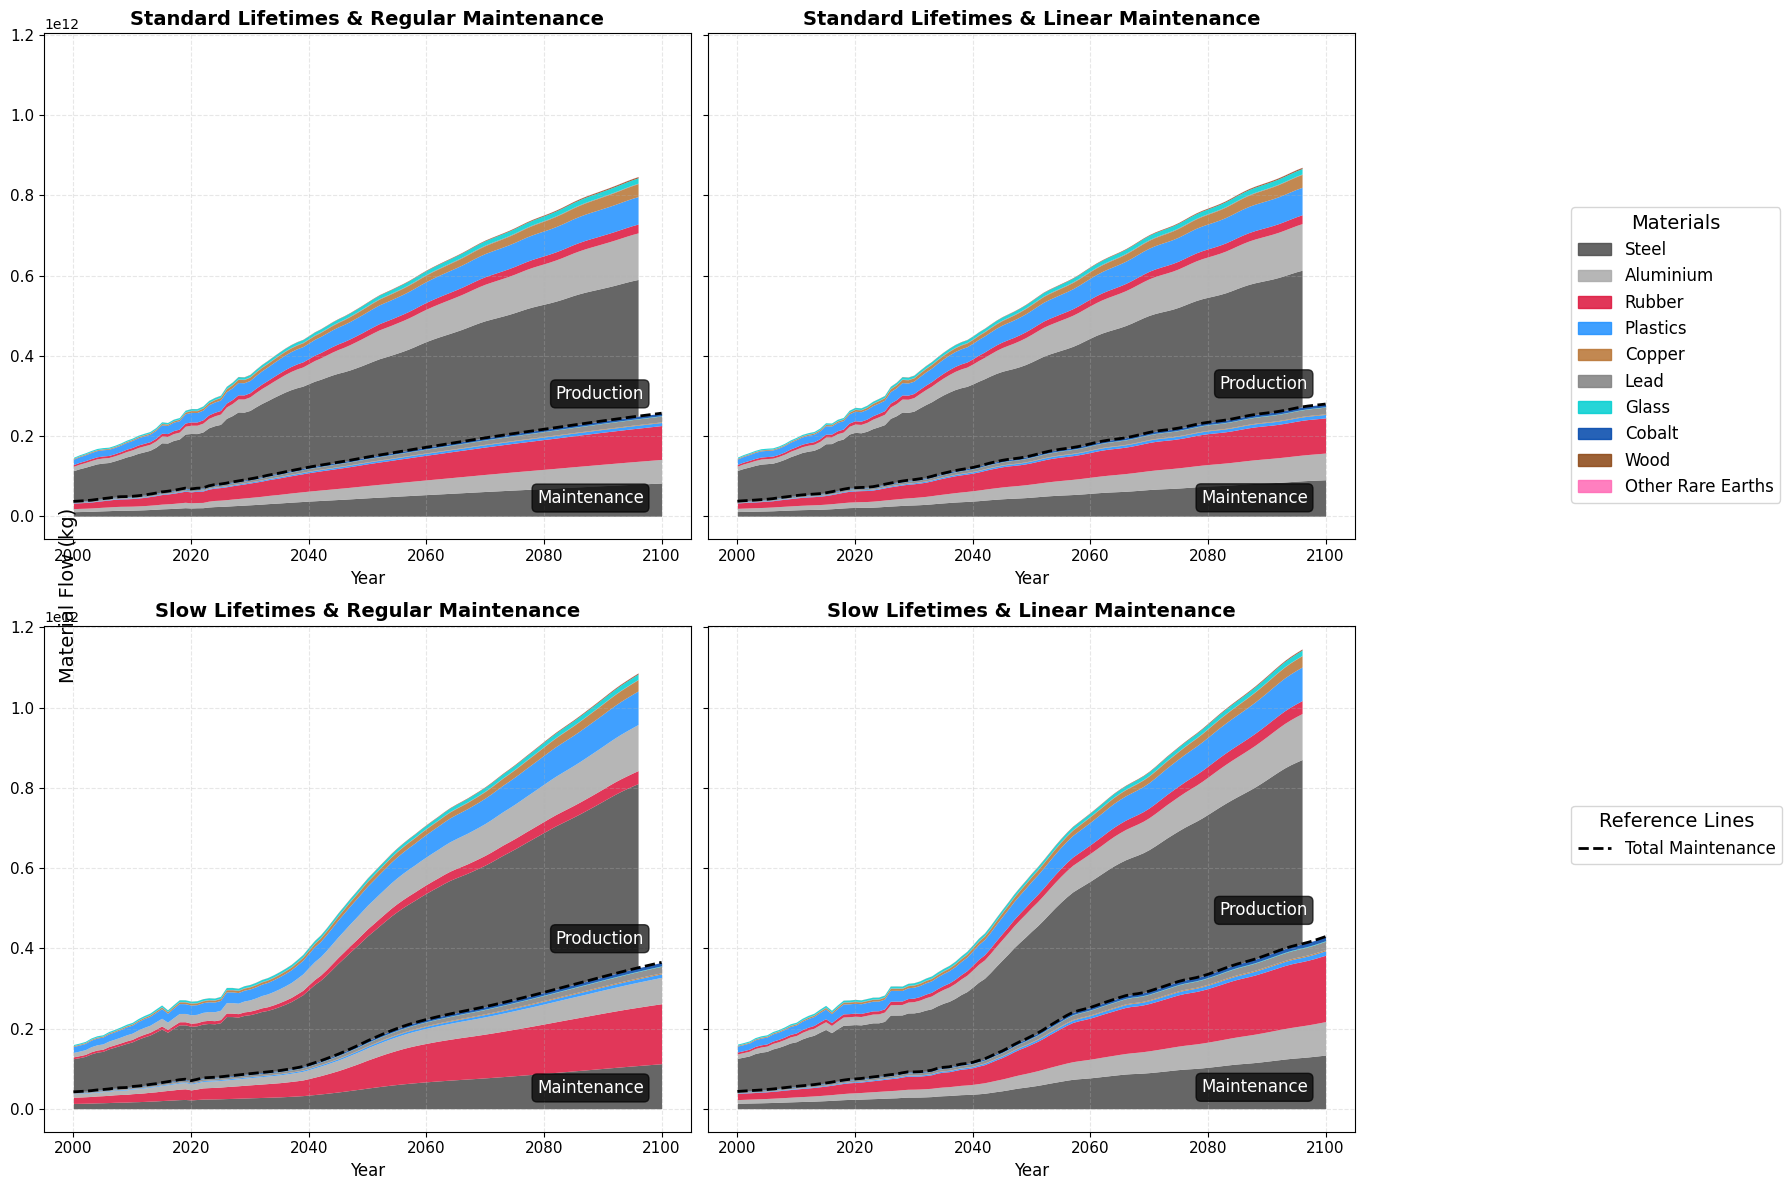

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from imagematerials.concepts import knowledge_graph


"""
Create 2x2 subplot showing maintenance + production for all four scenarios
with materials stacked and uniform coloring across plots.
"""

# Define material colors (customize as needed)
material_colors = {
    "Steel": "#4B4B4B",
    "Aluminium": "#A9A9A9",
    "Others": "#F0E68C",
    "Plastics": "#1E90FF",
    "Copper": "#B87333",
    "Rubber": "#DC143C",
    "Glass": "#00CED1",
    "Wood": "#8B4513",
    "Fluids": "#FF6347",
    "Lead": "#808080",
    "Neodymium": "#D2691E",  # will be removed after grouping
    "Cobalt": "#0047AB",  # cobalt blue
    "Other Rare Earths": "#FF69B4"  # pink
}

maintenance_types = [
    "Midi Buses",
    "Regular Buses", 
    "Trains",
    "High Speed Trains",
    "Light Commercial Vehicles",
    "Cars",
    "Medium Freight Trucks",
    "Heavy Freight Trucks",
]



# Helper function to process data for each scenario
def process_scenario_data(scenario_data):
    # Get maintenance and production data, sum over Region and Type
    maint_data = scenario_data['inflow_maintenance']
    prod_data = scenario_data["model"].inflow_materials.to_array()

    maint_data = knowledge_graph.aggregate_sum(maint_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region', 'Type'])
    prod_data = knowledge_graph.aggregate_sum(prod_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region', 'Type'])

        
    # Convert to pandas DataFrames
    maint_df = maint_data.to_pandas()
    prod_df = prod_data.to_pandas() 
    prod_df = prod_df.rolling(window=10, center=True).mean()
    
    # Process both dataframes similarly
    for df, name in [(maint_df, 'maintenance'), (prod_df, 'production')]:
        if df is None:
            continue
            
        print(f"{name} - Data shape: {df.shape}")
        print(f"{name} - Data columns: {df.columns.tolist()}")
        
        # Group rare earth elements
        rare_earths = ["Nd", "Mn", "Ni", "Ti", "Li"]
        existing_rare_earths = [re for re in rare_earths if re in df.columns]
        if existing_rare_earths:
            df["Other Rare Earths"] = df[existing_rare_earths].sum(axis=1)
            df.drop(columns=existing_rare_earths, inplace=True, errors="ignore")
        
        # Rename materials for better display
        rename_map = {
            "Pb": "Lead",
            "Co": "Cobalt", 
            "Cu": "Copper",
            "Al": "Aluminum"
        }
        df.rename(columns=rename_map, inplace=True)
        
        # Filter from 2000 onwards
        df = df[df.index >= 2010]
        
        # Keep only non-zero materials
        valid_materials = (df != 0).any(axis=0)
        df = df.loc[:, valid_materials]
    
    # Update the original dataframes
    if prod_df is not None:
        # Ensure both have same columns for consistent plotting
        all_materials = set(maint_df.columns) | set(prod_df.columns)
        for mat in all_materials:
            if mat not in maint_df.columns:
                maint_df[mat] = 0
            if mat not in prod_df.columns:
                prod_df[mat] = 0
        
        # Sort columns by total sum (maintenance + production)
        total_materials = maint_df + prod_df
        sorted_cols = total_materials.sum(axis=0).sort_values(ascending=False).index
        maint_df = maint_df[sorted_cols]
        prod_df = prod_df[sorted_cols]
    else:
        # Sort maintenance only
        sorted_cols = maint_df.sum(axis=0).sort_values(ascending=False).index
        maint_df = maint_df[sorted_cols]
    
    return maint_df, prod_df

# Process all scenarios
processed_data = {}
for scen_id, scen_data in all_output.items():
    print(f"\nProcessing scenario: {scen_id}")
    maint_df, prod_df = process_scenario_data(scen_data)
    if not maint_df.empty:
        processed_data[scen_id] = {'maintenance': maint_df, 'production': prod_df}


# Get all unique materials across scenarios for consistent coloring
all_materials = set()
for scen_data in processed_data.values():
    all_materials.update(scen_data['maintenance'].columns)
    if scen_data['production'] is not None:
        all_materials.update(scen_data['production'].columns)

# Update material colors to include any missing materials
for material in all_materials:
    if material not in material_colors:
        material_colors[material] = '#999999'  # Default gray

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each scenario
scenario_order = ['standard_constant', 'standard_linear', 'slow_constant', 'slow_linear']

for i, scen_id in enumerate(scenario_order):
    ax = axes[i]
    
    if scen_id not in processed_data:
        ax.text(0.5, 0.5, f"No data for\n{scen_id}", 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{scen_id} (No Data)", fontsize=14)
        continue
        
    maint_df = processed_data[scen_id]['maintenance']
    prod_df = processed_data[scen_id]['production']

   
    maint_df = maint_df[(maint_df.index >= 2000) & (maint_df.index <= 2100)]
    prod_df = prod_df[(prod_df.index >= 2000) & (prod_df.index <= 2100)]
    
    # Plot maintenance (bottom layer)
    colors_list = [material_colors.get(mat, '#999999') for mat in maint_df.columns]
    maint_df.plot.area(
        ax=ax, 
        stacked=True, 
        color=colors_list,
        alpha=0.85, 
        linewidth=0
    )
    ax.get_legend().remove()
    
    # Plot production stacked above maintenance
    if prod_df is not None:
        maintenance_total = maint_df.sum(axis=1)
        prod_bottom = maintenance_total.copy()
        
        for mat in prod_df.columns:
            if mat in prod_df.columns and not prod_df[mat].isna().all():
                top = prod_bottom + prod_df[mat]
                ax.fill_between(
                    prod_df.index,
                    prod_bottom,
                    top,
                    color=material_colors.get(mat, '#999999'),
                    alpha=0.85,
                    linewidth=0
                )
                prod_bottom = top
        
        # Plot total maintenance line
        ax.plot(
            maintenance_total.index, 
            maintenance_total, 
            color="black", 
            linewidth=2, 
            linestyle="--"
        )
    else:
        # Just maintenance
        maintenance_total = maint_df.sum(axis=1)
        ax.plot(
            maintenance_total.index, 
            maintenance_total, 
            color="black", 
            linewidth=2, 
            linestyle="--"
        )
    
    # Styling
    scenario_info = all_output[scen_id]
    title = scenario_info['label']
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Year", fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(visible=True, linestyle="--", alpha=0.3)
    
    # Add labels
    if len(maintenance_total) > 0:
        # Maintenance label
        ax.text(
            maintenance_total.index[-1] - 3,
            ax.get_ylim()[0] + 0.07 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            "Maintenance",
            color="white", fontsize=12, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
        )
        
        # Production label (if exists)
        if prod_df is not None:
            ax.text(
                maintenance_total.index[-1] - 3,
                maintenance_total.iloc[-1] * 1.1,
                "Production",
                color="white", fontsize=12, ha="right", va="bottom",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
            )

# Add shared Y label
fig.text(0.04, 0.5, 'Material Flow (kg)', va='center', rotation='vertical', fontsize=14)

# Create shared legend for materials
if processed_data:
    # Get materials from the first scenario for legend order
    first_scenario = list(processed_data.values())[0]
    legend_materials = first_scenario['maintenance'].columns.tolist()
    
    # Create legend handles
    legend_handles = [mpatches.Rectangle((0,0),1,1, color=material_colors[mat], alpha=0.85) 
                        for mat in legend_materials]
    
    # Add materials legend
    fig.legend(
        legend_handles, 
        legend_materials,
        title="Materials", 
        bbox_to_anchor=(0.98, 0.7), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )
    
    # Add reference line legend
    ref_handles = [plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--')]
    ref_labels = ["Total Maintenance"]
    
    fig.legend(
        ref_handles, 
        ref_labels,
        title="Reference Lines", 
        bbox_to_anchor=(0.98, 0.3), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )

# Layout optimization
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legends
plt.show()



Processing scenario: standard_linear
maintenance - Data shape: (201, 3)
maintenance - Data columns: ['Buses', 'Trains', 'High Speed Trains']
production - Data shape: (201, 3)
production - Data columns: ['Buses', 'Trains', 'High Speed Trains']

Processing scenario: standard_constant
maintenance - Data shape: (201, 3)
maintenance - Data columns: ['Buses', 'Trains', 'High Speed Trains']
production - Data shape: (201, 3)
production - Data columns: ['Buses', 'Trains', 'High Speed Trains']

Processing scenario: slow_constant


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of 

maintenance - Data shape: (201, 3)
maintenance - Data columns: ['Buses', 'Trains', 'High Speed Trains']
production - Data shape: (201, 3)
production - Data columns: ['Buses', 'Trains', 'High Speed Trains']

Processing scenario: slow_linear
maintenance - Data shape: (201, 3)
maintenance - Data columns: ['Buses', 'Trains', 'High Speed Trains']
production - Data shape: (201, 3)
production - Data columns: ['Buses', 'Trains', 'High Speed Trains']


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


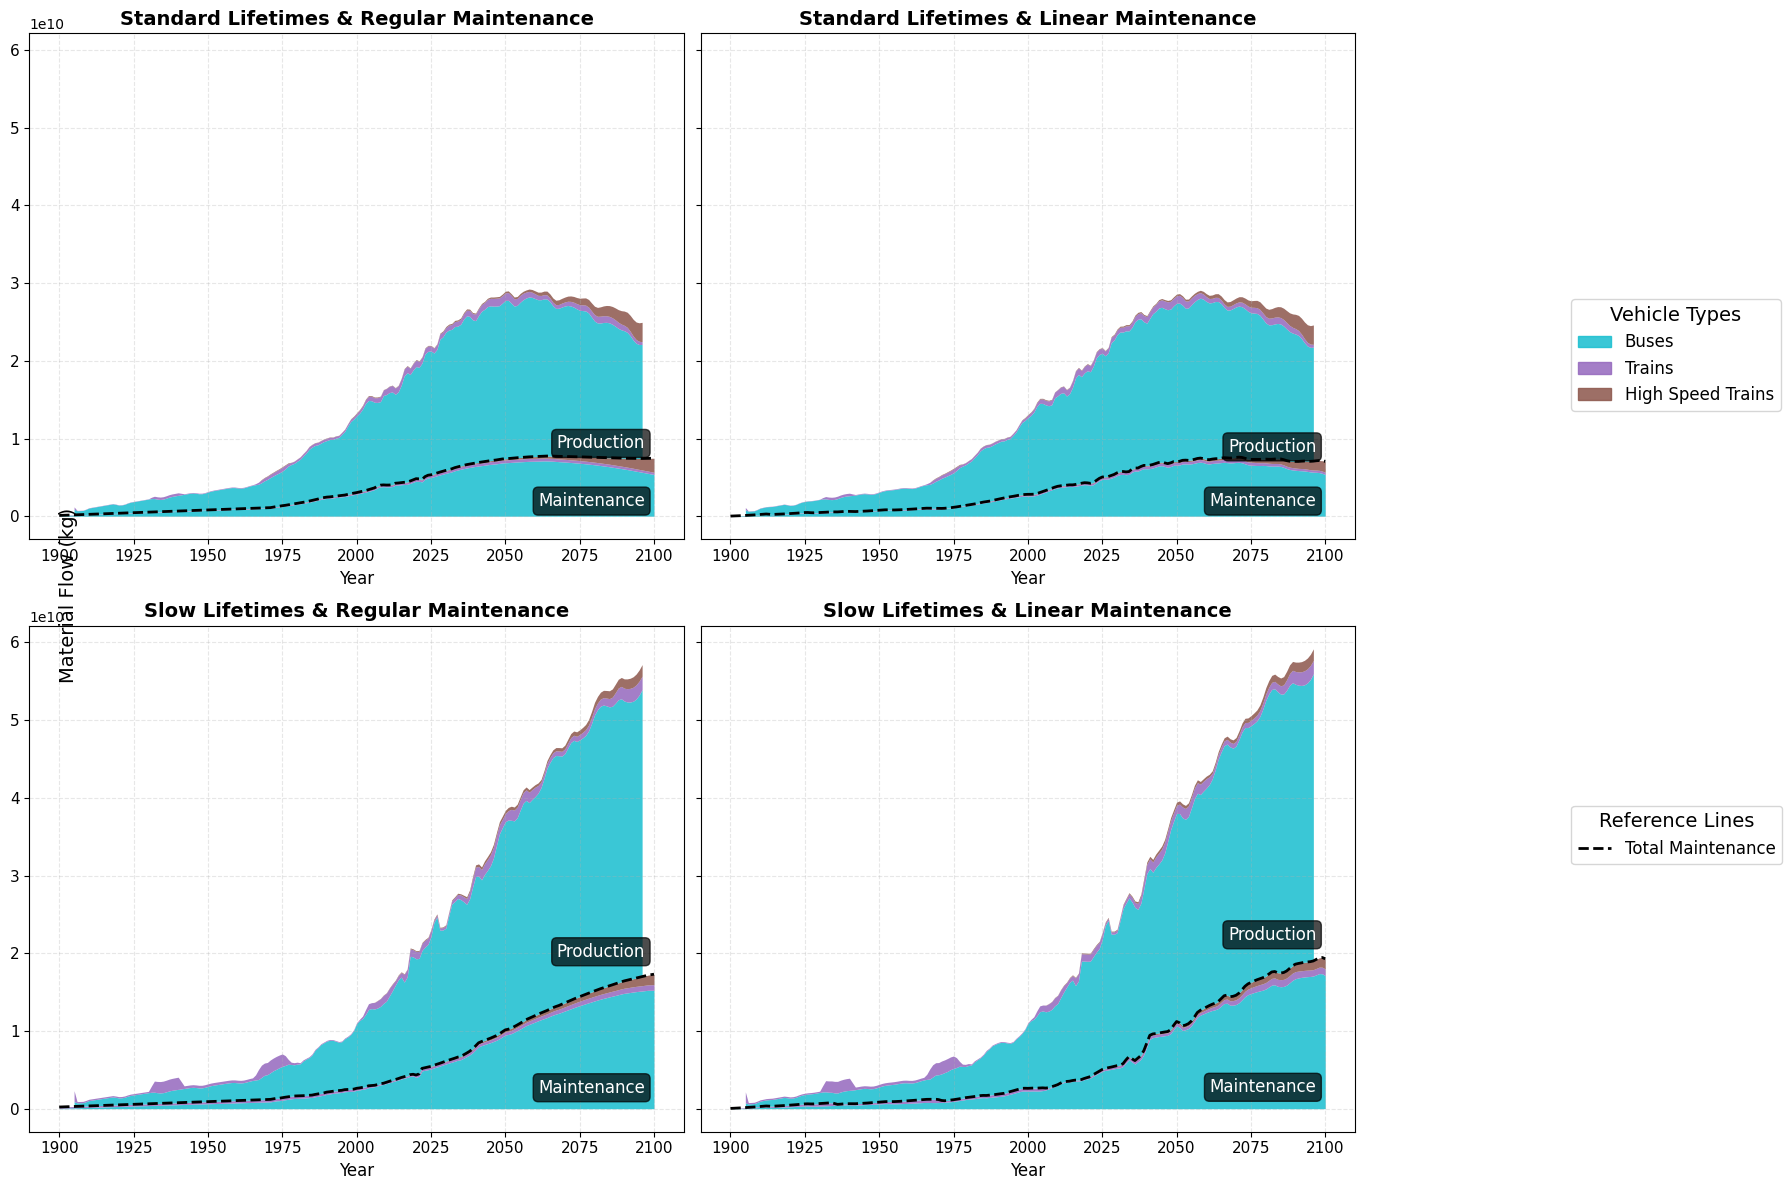

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from imagematerials.concepts import knowledge_graph

"""
Create 2x2 subplot showing maintenance + production for all four scenarios
with vehicle types stacked and uniform coloring across plots.
"""

# Define vehicle type colors (customize as needed)
type_colors = {
    "Cars": "#1f77b4",
    "Light Commercial Vehicles": "#ff7f0e",
    "Regular Buses": "#2ca02c",
    "Midi Buses": "#d62728",
    "Trains": "#9467bd",
    "High Speed Trains": "#8c564b",
    "Medium Freight Trucks": "#e377c2",
    "Heavy Freight Trucks": "#7f7f7f",
    "Trucks": "#bcbd22",
    "Buses": "#17becf",
}

maintenance_types = [
    "Buses",
    "Trains",
    "High Speed Trains",
    "Cars",
    "Trucks",
]

# Helper function to process data for each scenario (modified for vehicle types)
def process_scenario_data_by_type(scenario_data):
    # Get maintenance and production data, sum over Region and material (keep Type)
    maint_data = scenario_data['inflow_maintenance']
    prod_data = scenario_data["model"].inflow_materials.to_array()

    # Aggregate by vehicle types and sum over regions and materials
    maint_data = knowledge_graph.aggregate_sum(maint_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region', 'material'])
    prod_data = knowledge_graph.aggregate_sum(prod_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region', 'material'])

    # Convert to pandas DataFrames
    maint_df = maint_data.to_pandas().T
    prod_df = prod_data.to_pandas().T 
    prod_df = prod_df.rolling(window=10, center=True).mean()
    
    # Process both dataframes
    for df, name in [(maint_df, 'maintenance'), (prod_df, 'production')]:
        if df is None:
            continue
            
        print(f"{name} - Data shape: {df.shape}")
        print(f"{name} - Data columns: {df.columns.tolist()}")
        

        
        # Keep only non-zero vehicle types
        valid_types = (df != 0).any(axis=0)
        df = df.loc[:, valid_types]
    
    # Update the original dataframes
    if prod_df is not None:
        # Ensure both have same columns for consistent plotting
        all_types = set(maint_df.columns) | set(prod_df.columns)
        for vtype in all_types:
            if vtype not in maint_df.columns:
                maint_df[vtype] = 0
            if vtype not in prod_df.columns:
                prod_df[vtype] = 0
        
        # Sort columns by total sum (maintenance + production)
        total_types = maint_df + prod_df
        sorted_cols = total_types.sum(axis=0).sort_values(ascending=False).index
        maint_df = maint_df[sorted_cols]
        prod_df = prod_df[sorted_cols]
    else:
        # Sort maintenance only
        sorted_cols = maint_df.sum(axis=0).sort_values(ascending=False).index
        maint_df = maint_df[sorted_cols]
    
    return maint_df, prod_df

# Process all scenarios
processed_data_by_type = {}
for scen_id, scen_data in all_output.items():
    print(f"\nProcessing scenario: {scen_id}")
    maint_df, prod_df = process_scenario_data_by_type(scen_data)
    if not maint_df.empty:
        processed_data_by_type[scen_id] = {'maintenance': maint_df, 'production': prod_df}

# Get all unique vehicle types across scenarios for consistent coloring
all_types = set()
for scen_data in processed_data_by_type.values():
    all_types.update(scen_data['maintenance'].columns)
    if scen_data['production'] is not None:
        all_types.update(scen_data['production'].columns)

# Update type colors to include any missing vehicle types
for vtype in all_types:
    if vtype not in type_colors:
        type_colors[vtype] = '#999999'  # Default gray

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()

# Plot each scenario
scenario_order = ['standard_constant', 'standard_linear', 'slow_constant', 'slow_linear']

for i, scen_id in enumerate(scenario_order):
    ax = axes[i]
    
    if scen_id not in processed_data_by_type:
        ax.text(0.5, 0.5, f"No data for\n{scen_id}", 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{scen_id} (No Data)", fontsize=14)
        continue
        
    maint_df = processed_data_by_type[scen_id]['maintenance']
    prod_df = processed_data_by_type[scen_id]['production']

    maint_df = maint_df[(maint_df.index >= 1900) & (maint_df.index <= 2100)]
    prod_df = prod_df[(prod_df.index >= 1900) & (prod_df.index <= 2100)]
    
    # Plot maintenance (bottom layer)
    colors_list = [type_colors.get(vtype, '#999999') for vtype in maint_df.columns]
    maint_df.plot.area(
        ax=ax, 
        stacked=True, 
        color=colors_list,
        alpha=0.85, 
        linewidth=0
    )
    ax.get_legend().remove()
    
    # Plot production stacked above maintenance
    if prod_df is not None:
        maintenance_total = maint_df.sum(axis=1)
        prod_bottom = maintenance_total.copy()
        
        for vtype in prod_df.columns:
            if vtype in prod_df.columns and not prod_df[vtype].isna().all():
                top = prod_bottom + prod_df[vtype]
                ax.fill_between(
                    prod_df.index,
                    prod_bottom,
                    top,
                    color=type_colors.get(vtype, '#999999'),
                    alpha=0.85,
                    linewidth=0
                )
                prod_bottom = top
        
        # Plot total maintenance line
        ax.plot(
            maintenance_total.index, 
            maintenance_total, 
            color="black", 
            linewidth=2, 
            linestyle="--"
        )
    else:
        # Just maintenance
        maintenance_total = maint_df.sum(axis=1)
        ax.plot(
            maintenance_total.index, 
            maintenance_total, 
            color="black", 
            linewidth=2, 
            linestyle="--"
        )
    
    # Styling
    scenario_info = all_output[scen_id]
    title = scenario_info['label']
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Year", fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(visible=True, linestyle="--", alpha=0.3)
    
    # Add labels
    if len(maintenance_total) > 0:
        # Maintenance label
        ax.text(
            maintenance_total.index[-1] - 3,
            ax.get_ylim()[0] + 0.07 * (ax.get_ylim()[1] - ax.get_ylim()[0]),
            "Maintenance",
            color="white", fontsize=12, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
        )
        
        # Production label (if exists)
        if prod_df is not None:
            ax.text(
                maintenance_total.index[-1] - 3,
                maintenance_total.iloc[-1] * 1.1,
                "Production",
                color="white", fontsize=12, ha="right", va="bottom",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7)
            )

# Add shared Y label
fig.text(0.04, 0.5, 'Material Flow (kg)', va='center', rotation='vertical', fontsize=14)

# Create shared legend for vehicle types
if processed_data_by_type:
    # Get vehicle types from the first scenario for legend order
    first_scenario = list(processed_data_by_type.values())[0]
    legend_types = first_scenario['maintenance'].columns.tolist()
    
    # Create legend handles
    legend_handles = [mpatches.Rectangle((0,0),1,1, color=type_colors[vtype], alpha=0.85) 
                        for vtype in legend_types]
    
    # Add vehicle types legend
    fig.legend(
        legend_handles, 
        legend_types,
        title="Vehicle Types", 
        bbox_to_anchor=(0.98, 0.7), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )
    
    # Add reference line legend
    ref_handles = [plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--')]
    ref_labels = ["Total Maintenance"]
    
    fig.legend(
        ref_handles, 
        ref_labels,
        title="Reference Lines", 
        bbox_to_anchor=(0.98, 0.3), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )

# Layout optimization
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Space for legends
plt.show()

c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
C:\Users\5982758\AppData\Local\Temp\ipykernel_40764\1659746094.py:73: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prod_df_full = prod_df_full.fillna(method='bfill').fillna(method='ffill')  # Fill NaNs from rolling window
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3

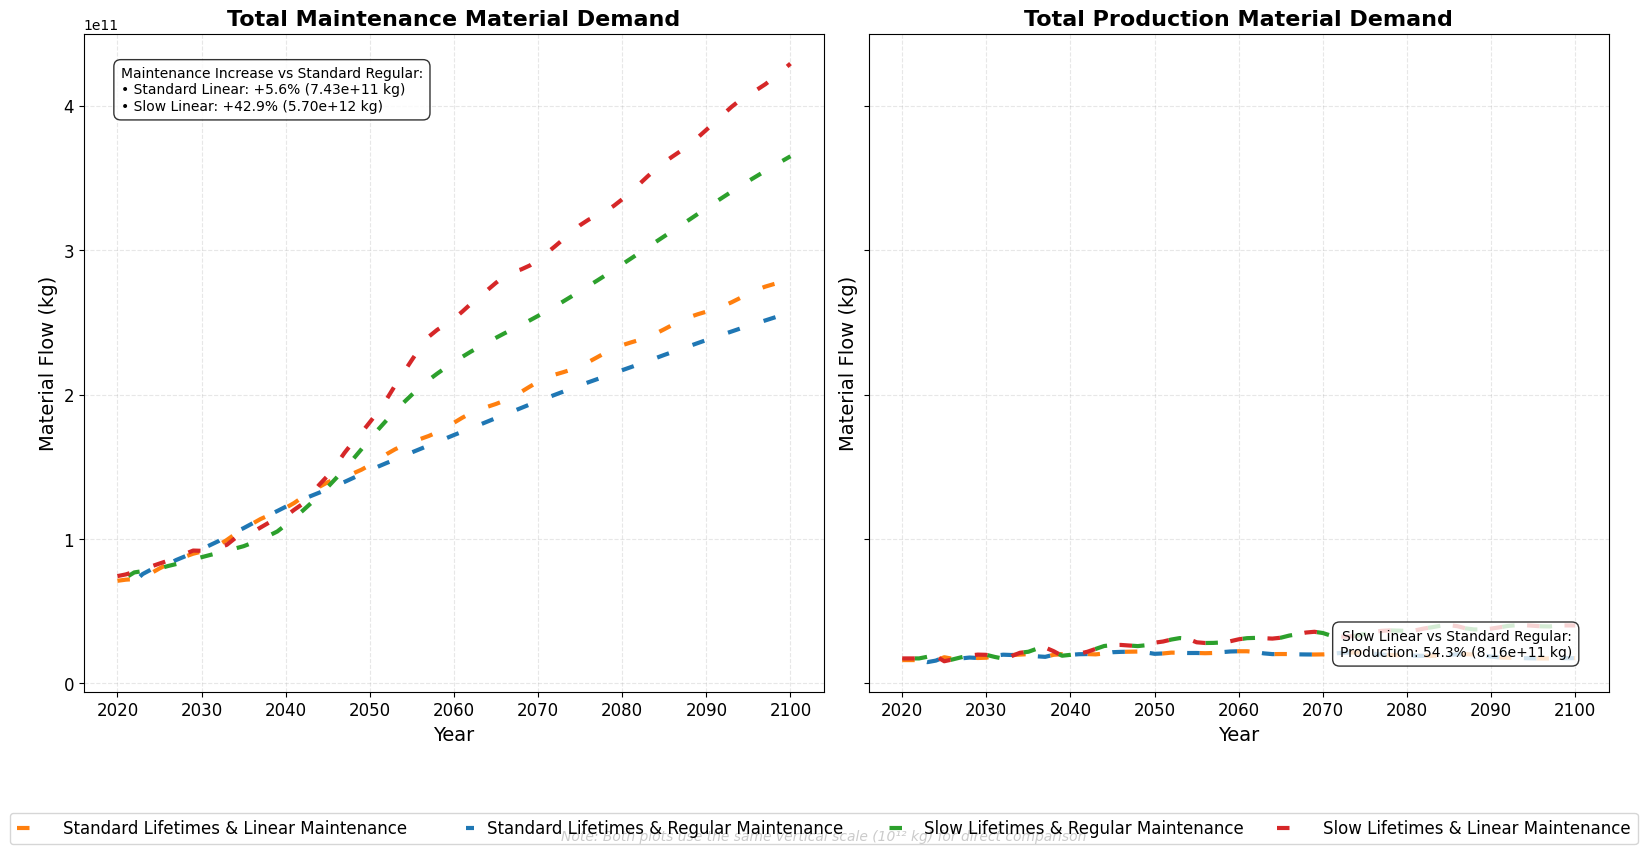


=== Summary Statistics (2050) ===
Standard Lifetimes & Linear Maintenance:
  Maintenance (2050): 1.51e+11 kg
  Production (2050): 1.23e+12 kg
  M/P Ratio: 0.123
Standard Lifetimes & Regular Maintenance:
  Maintenance (2050): 1.48e+11 kg
  Production (2050): 1.23e+12 kg
  M/P Ratio: 0.120


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of 

Slow Lifetimes & Regular Maintenance:
  Maintenance (2050): 1.69e+11 kg
  Production (2050): 9.01e+11 kg
  M/P Ratio: 0.188
Slow Lifetimes & Linear Maintenance:
  Maintenance (2050): 1.81e+11 kg
  Production (2050): 9.01e+11 kg
  M/P Ratio: 0.201


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from imagematerials.concepts import knowledge_graph

def plot_maintenance_production_comparison(all_output, year_range=(2020, 2100), scenarios=None):
    """
    Create side-by-side plots comparing total maintenance and production material demand across scenarios
    with improved visibility and comparable scales.
    """
    if scenarios is None:
        scenarios = list(all_output.keys())
    
    # Define colors and line styles for better distinction
    scenario_colors = {
        'standard_constant': '#1f77b4',  # blue
        'standard_linear': '#ff7f0e',    # orange
        'slow_constant': '#2ca02c',      # green
        'slow_linear': '#d62728'         # red
    }
    
    line_styles = {
        'standard_constant': (3, (3, 6)),            # dashed with offset 0
        'standard_linear': (0, (3, 6)),              # same dash pattern but offset by 1
        'slow_constant': (6, (3, 6)),                # same dash pattern but offset by 2
        'slow_linear': (0, (3, 6)),                   # same dash pattern but offset by 3
    }
    
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9), sharey=True)  # Set sharey=True for same y-scale
    
    max_value = 0  # Track maximum value for scaling

        # Calculate sums for the entire period and store data for each scenario
    scenario_data = {}
    
    # Process each scenario
    for scenario in scenarios:
        if scenario not in all_output:
            print(f"Warning: Scenario {scenario} not found!")
            continue
        
        # Get scenario label, color and line style
        label = all_output[scenario]['label']
        color = scenario_colors.get(scenario, '#999999')
        linestyle = line_styles.get(scenario, (0, (5, 2)))
        
        # --- MAINTENANCE PLOT (Left) ---
        maint_array = all_output[scenario]['inflow_maintenance'].sum(dim=['Region', 'Type', 'material'])
        maint_df = maint_array.to_pandas()
        maint_df_full = maint_df[(maint_df.index >= year_range[0]) & (maint_df.index <= year_range[1])]
        
        # Update max value
        max_value = max(max_value, maint_df_full.max())
        
        # Calculate total maintenance sum for this scenario
        maint_sum = maint_df_full[(maint_df_full.index >= 2025) & (maint_df_full.index <= 2100)].sum()
        
        # Plot with offset dashed lines
        ax1.plot(maint_df_full.index, maint_df_full, 
                 label=label, 
                 color=color,
                 linestyle=linestyle,
                 linewidth=3)
        
        # --- PRODUCTION PLOT (Right) ---
        prod_array = all_output[scenario]['model'].inflow_materials.to_array().sum(dim=['Region', 'material'])
        prod_array = knowledge_graph.aggregate_sum(prod_array, output_coords=maintenance_types, dim="Type").sum(dim=[ 'Type'])
        prod_df = prod_array.to_pandas()
        prod_df_full = prod_df[(prod_df.index >= year_range[0]) & (prod_df.index <= year_range[1])]
        
        # Apply rolling mean to smooth production data
        prod_df_full = prod_df_full.rolling(window=5, center=True).mean()
        prod_df_full = prod_df_full.fillna(method='bfill').fillna(method='ffill')  # Fill NaNs from rolling window
        
        # Calculate total production sum for this scenario
        prod_sum = prod_df_full[(prod_df_full.index >= 2025) & (prod_df_full.index <= 2100)].sum()
        
        # Update max value from production too
        max_value = max(max_value, prod_df_full.max())
        
        # Plot with offset dashed lines
        ax2.plot(prod_df_full.index, prod_df_full, 
                 label=label, 
                 color=color,
                 linestyle=linestyle,
                 linewidth=3)
        
        # Store data for later use in annotations
        scenario_data[scenario] = {
            'maintenance_total': maint_sum,
            'production_total': prod_sum,
            'label': label
        }
    

    
    
    # Add grid for easier reading of values
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax2.grid(True, linestyle='--', alpha=0.3)
    
    # --- Style the plots ---
    ax1.set_title('Total Maintenance Material Demand', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Year', fontsize=14)
    ax1.set_ylabel('Material Flow (kg)', fontsize=14)
    ax1.tick_params(labelsize=12)
    
    ax2.set_title('Total Production Material Demand', fontsize=16, fontweight='bold')
    ax2.set_xlabel('Year', fontsize=14)
    ax2.set_ylabel('Material Flow (kg)', fontsize=14)
    ax2.tick_params(labelsize=12)

    # Add annotations with statistics in the corners
    if 'standard_constant' in scenario_data:
        base_maint = scenario_data['standard_constant']['maintenance_total']
        base_prod = scenario_data['standard_constant']['production_total']
        
        # Top left corner of maintenance plot - Compare linear to constant maintenance
        annotation_text = "Maintenance Increase vs Standard Regular:\n"
        
        if 'standard_linear' in scenario_data:
            sl_maint = scenario_data['standard_linear']['maintenance_total']
            diff = sl_maint - base_maint
            pct = (diff / base_maint) * 100
            annotation_text += f"• Standard Linear: +{pct:.1f}% ({diff:.2e} kg)\n"
        
        if 'slow_linear' in scenario_data:
            sl_maint = scenario_data['slow_linear']['maintenance_total']
            diff = sl_maint - base_maint
            pct = (diff / base_maint) * 100
            annotation_text += f"• Slow Linear: +{pct:.1f}% ({diff:.2e} kg)"
            
        ax1.text(0.05, 0.95, annotation_text,
                 transform=ax1.transAxes,
                 fontsize=10,
                 verticalalignment='top',
                 horizontalalignment='left',
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8))
        
        # Bottom right corner of production plot - Compare slow linear to standard constant
        if 'slow_linear' in scenario_data:
            sl_prod = scenario_data['slow_linear']['production_total']
            prod_diff = sl_prod - base_prod
            prod_pct = (prod_diff / base_prod) * 100
            
            prod_annotation = f"Slow Linear vs Standard Regular:\n"
            prod_annotation += f"Production: {prod_pct:.1f}% ({prod_diff:.2e} kg)"
            
            ax2.text(0.95, 0.05, prod_annotation,
                     transform=ax2.transAxes,
                     fontsize=10,
                     verticalalignment='bottom',
                     horizontalalignment='right',
                     bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8))
    
    
    # Create single legend for both plots
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, 
               loc='upper center', 
               bbox_to_anchor=(0.5, 0.05),
               ncol=len(scenarios),
               fontsize=12)
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])  # Make room for legend at bottom
    
    # Add text annotation to explain units
    fig.text(0.5, 0.01, "Note: Both plots use the same vertical scale (10¹² kg) for direct comparison", 
             ha='center', fontsize=10, style='italic')
    
    plt.show()
    
    # Print summary statistics
    print("\n=== Summary Statistics (2050) ===")
    for scenario in scenarios:
        if scenario not in all_output:
            continue
            
        # Get 2050 values
        maint_array = all_output[scenario]['inflow_maintenance'].sum(dim=['Region', 'Type', 'material'])
        maint_df = maint_array.to_pandas()
        maint_2050 = maint_df.loc[2050] if 2050 in maint_df.index else np.nan
        
        prod_array = all_output[scenario]['model'].inflow_materials.to_array().sum(dim=['Region', 'Type', 'material'])
        prod_df = prod_array.to_pandas()
        prod_2050 = prod_df.loc[2050] if 2050 in prod_df.index else np.nan
        
        # Calculate ratio
        ratio = maint_2050 / prod_2050 if not np.isnan(prod_2050) and prod_2050 > 0 else np.nan
        
        print(f"{all_output[scenario]['label']}:")
        print(f"  Maintenance (2050): {maint_2050:.2e} kg")
        print(f"  Production (2050): {prod_2050:.2e} kg")
        print(f"  M/P Ratio: {ratio:.3f}")

# Call the function with all scenarios and year range 2020-2100
plot_maintenance_production_comparison(all_output, year_range=(2020, 2100))

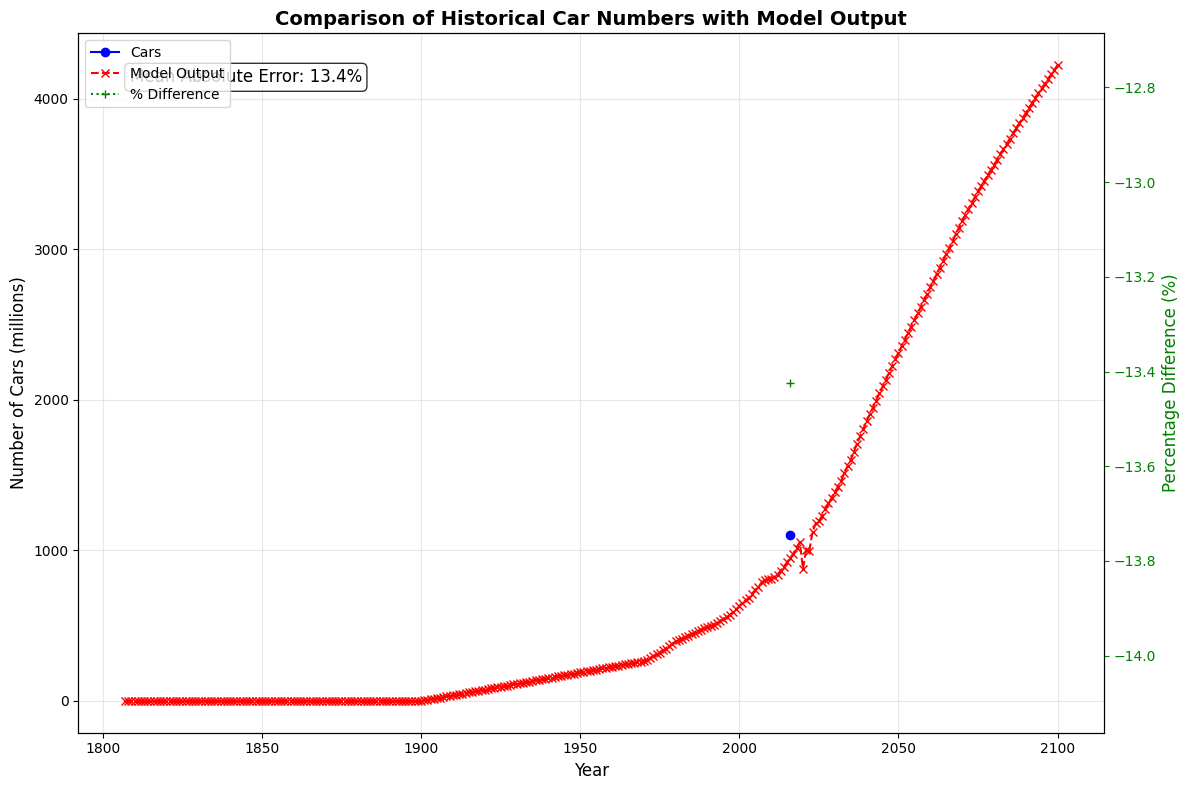


Car numbers comparison (millions):
Year      Historical     Model          Difference% Diff    
------------------------------------------------------------
2016      1100.0         952.3          -147.7    -13.4     %


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define the historical data (in millions of cars)
historical_data = {
    2016: 1100,
}

# Extract cars data from stocks
cars = vhc_sector.prep_data["stocks"].sum(dim=["Region"])
cars = knowledge_graph.aggregate_sum(cars, output_coords=["Cars"], dim="Type").sel(Type="Cars")

# Convert to millions for comparison
cars_millions = cars / 1_000_000

# Create a pandas DataFrame from historical data for easy plotting
historical_df = pd.DataFrame.from_dict(historical_data, orient='index', columns=['Cars'])
historical_df.index.name = 'Year'

# Create figure and axis objects
fig, ax = plt.subplots(figsize=(12, 8))

# Plot historical data
historical_df.plot(marker='o', linestyle='-', color='blue', label='Historical Data', ax=ax)

# Plot model data for cars
cars_millions.plot(marker='x', linestyle='--', color='red', label='Model Output', ax=ax)

# Add a plot showing the percentage difference
ax2 = ax.twinx()
years_to_compare = [y for y in historical_df.index if y in cars_millions.coords['Time'].values]
percentage_diff = ((cars_millions.sel(Time=years_to_compare) - 
                  historical_df.loc[years_to_compare, 'Cars'].values) / 
                  historical_df.loc[years_to_compare, 'Cars'].values) * 100

ax2.plot(years_to_compare, percentage_diff, 
        color='green', linestyle=':', marker='+', label='% Difference')
ax2.set_ylabel('Percentage Difference (%)', color='green', fontsize=12)
ax2.tick_params(axis='y', colors='green')
ax2.grid(False)

# Customize primary axis appearance
ax.set_title('Comparison of Historical Car Numbers with Model Output', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Cars (millions)', fontsize=12)
ax.grid(True, alpha=0.3)

# Add both legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Add text showing the average percentage error
if len(percentage_diff) > 0:
    avg_error = np.abs(percentage_diff).mean()
    ax.text(0.05, 0.95, f'Mean Absolute Error: {avg_error:.1f}%', 
            transform=ax.transAxes, fontsize=12, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print a table of values for comparison
print("\nCar numbers comparison (millions):")
print("="*60)
print(f"{'Year':<10}{'Historical':<15}{'Model':<15}{'Difference':<10}{'% Diff':<10}")
print("-"*60)

for year in years_to_compare:
    historical_val = historical_df.loc[year, 'Cars']
    model_val = float(cars_millions.sel(Time=year))
    diff = model_val - historical_val
    pct_diff = (diff / historical_val) * 100
    print(f"{year:<10}{historical_val:<15.1f}{model_val:<15.1f}{diff:<10.1f}{pct_diff:<10.1f}%")

print("="*60)



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define simulation parameters
time_start = 1920
complete_timeline = prism.Timeline(time_start, 2100, 1)
simulation_timeline = prism.Timeline(1920, 2100, 1)

scenario_list2 = {
    'slow_linear_capped': {
        'label': 'Slow Lifetimes & Linear Maintenance (Capped)',
        'circular_scen': 'slow',
        'maintenance_scen': 'linear',
        'cap_at_lifetime': True
    },
    'slow_linear_uncapped': {
        'label': 'Slow Lifetimes & Linear Maintenance (Uncapped)',
        'circular_scen': 'slow',
        'maintenance_scen': 'linear',
        'cap_at_lifetime': False
    },
    'slow_constant': {
        'label': 'Standard Lifetimes & Regular Maintenance',
        'circular_scen': 'standard',
        'maintenance_scen': 'constant',
        'cap_at_lifetime': False
    },
}

all_output2 = {}

for scen_id, scenario_config in scenario_list2.items():   
    print(f"\n=== Running Scenario: {scen_id} ===")
    
    # Select the appropriate sector data based on circular economy scenario
    if scenario_config['circular_scen'] == 'standard':
        sector_data = vhc_sector
        if scenario_config["cap_at_lifetime"]==True:
            sector_data.all_data["cap_at_lifetime"]=True
            print("Capping maintenance at lifetime")
        else:
            sector_data.all_data["cap_at_lifetime"]=False
            print("Not capping maintenance at lifetime")
        print("Using standard sector data")
    elif scenario_config['circular_scen'] == 'slow':
        sector_data = vhc_sector_slow
        if scenario_config["cap_at_lifetime"]==True:
            sector_data.all_data["cap_at_lifetime"]=True
            print("Capping maintenance at lifetime")
        else:
            sector_data.all_data["cap_at_lifetime"]=False
            print("Not capping maintenance at lifetime")
        print("Using slow circular economy sector data")
    
    # Create factory with appropriate sector data
    factory = ModelFactory(
        sector_data, complete_timeline
    ).add(GenericStocks
    ).add(GenericMaterials)
    
    # Add the appropriate maintenance model based on maintenance scenario
    if scenario_config['maintenance_scen'] == 'constant':
        factory = factory.add(Maintenance)
        print("Using constant maintenance model")
    elif scenario_config['maintenance_scen'] == 'linear':
        if 'cap_at_lifetime' in scenario_config:
            MaintenanceLinear.cap_at_lifetime = scenario_config['cap_at_lifetime']
            cap_status = "capped" if scenario_config['cap_at_lifetime'] else "uncapped"
            print(f"Using linear maintenance model ({cap_status} at lifetime)")
        
        # Add the original class (now with modified attribute)
        factory = factory.add(MaintenanceLinear)
        
    
    # Finish model creation
    model = factory.finish()
    
    # Run simulation
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model.simulate(simulation_timeline)
    
    # Store results
    all_output2[scen_id] = {
        'model': model,
        'inflow_maintenance': model.inflow_maintenance.to_array(),
        'circular_scenario': scenario_config['circular_scen'],
        'maintenance_scenario': scenario_config['maintenance_scen'],
        'cap_at_lifetime': scenario_config["cap_at_lifetime"],  # Default is True
        'label': scenario_config['label']
    }
    


print(f"\n=== All {len(all_output2)} scenarios completed successfully ===")
print("Available scenarios:", list(all_output2.keys()))


=== Running Scenario: slow_linear_capped ===
Capping maintenance at lifetime
Using slow circular economy sector data
Using linear maintenance model (capped at lifetime)
Initialized MaintenanceLinear with 47 maintenance types
Capping lifetime is set to True
2100
=== Running Scenario: slow_linear_uncapped ===
Not capping maintenance at lifetime
Using slow circular economy sector data
Using linear maintenance model (uncapped at lifetime)
Initialized MaintenanceLinear with 47 maintenance types
Capping lifetime is set to False
2100
=== Running Scenario: standard_constant ===
Not capping maintenance at lifetime
Using standard sector data
Using constant maintenance model
2100
=== All 3 scenarios completed successfully ===
Available scenarios: ['slow_linear_capped', 'slow_linear_uncapped', 'standard_constant']


c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\5982758\AppData\Local\anaconda3\envs\materials\lib\site-packages\xarray\core\variable.py:338: UnitStrippedWarning: The unit of 

Slow Lifetimes & Linear Maintenance (Capped): Total maintenance 2020-2100: 1.78e+13 kg
Slow Lifetimes & Linear Maintenance (Uncapped): Total maintenance 2020-2100: 1.94e+13 kg
Standard Lifetimes & Regular Maintenance: Total maintenance 2020-2100: 1.36e+13 kg


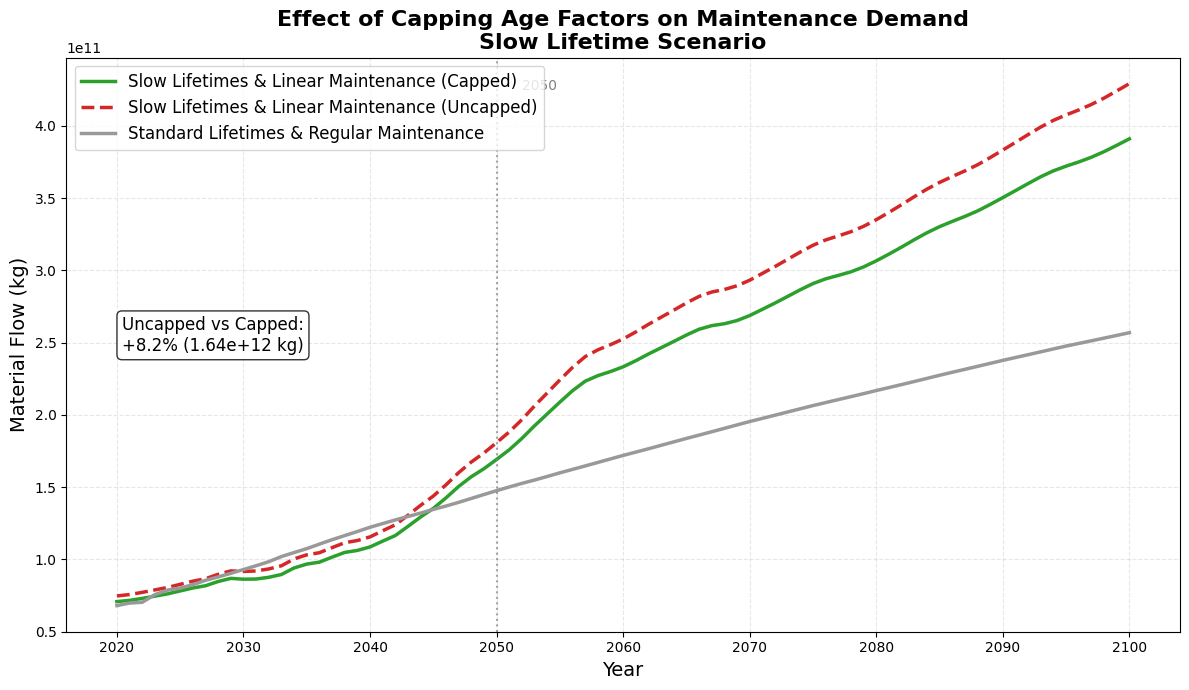

In [ ]:
def plot_capping_comparison(all_output, year_range=(2020, 2100)):
    """
    Create a comparison plot of maintenance demand between capped and uncapped age factors
    for slow linear scenarios.
    """
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Define colors
    colors = {
        'slow_linear_capped': '#2ca02c',    # green
        'slow_linear_uncapped': '#d62728',  # red
    }
    
    # Define line styles
    line_styles = {
        'slow_linear_capped': '-',          # solid
        'slow_linear_uncapped': '--',       # dashed
    }
    
    legend_entries = []
    
    # Plot data for selected scenarios
    for scenario_id in ['slow_linear_capped', 'slow_linear_uncapped',"standard_constant"]:
        if scenario_id not in all_output:
            print(f"Warning: Scenario {scenario_id} not found!")
            continue
            
        scenario_data = all_output[scenario_id]
        label = scenario_data['label']
        
        # Get maintenance data
        maint_array = scenario_data['inflow_maintenance'].sum(dim=['Region', 'Type', 'material'])
        maint_df = maint_array.to_pandas()
        maint_df = maint_df[(maint_df.index >= year_range[0]) & (maint_df.index <= year_range[1])]
        
        # Plot the line
        line, = ax.plot(maint_df.index, maint_df, 
                        label=label,
                        color=colors.get(scenario_id, '#999999'),
                        linestyle=line_styles.get(scenario_id, '-'),
                        linewidth=2.5)
        
        legend_entries.append(line)
        
        # Calculate total maintenance (sum)
        total_maint = maint_df.sum()
        print(f"{label}: Total maintenance {year_range[0]}-{year_range[1]}: {total_maint:.2e} kg")
    
    # Calculate and display percentage difference
    if 'slow_linear_capped' in all_output and 'slow_linear_uncapped' in all_output:
        capped_total = all_output['slow_linear_capped']['inflow_maintenance'].sum(
            dim=['Region', 'Type', 'material', 'time']).values
        uncapped_total = all_output['slow_linear_uncapped']['inflow_maintenance'].sum(
            dim=['Region', 'Type', 'material', 'time']).values
        
        pct_diff = ((uncapped_total - capped_total) / capped_total) * 100
        abs_diff = uncapped_total - capped_total
        
        # Add annotation about difference
        text = f"Uncapped vs Capped:\n+{pct_diff:.1f}% ({abs_diff:.2e} kg)"
        ax.text(0.05, 0.55, text, 
                transform=ax.transAxes, 
                fontsize=12, 
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Add vertical line at 2050 for reference
    ax.axvline(x=2050, color='gray', linestyle=':', alpha=0.7)
    ax.text(2052, ax.get_ylim()[1]*0.95, '2050', color='gray')
    
    # Styling
    ax.set_title('Effect of Capping Age Factors on Maintenance Demand\nSlow Lifetime Scenario', 
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('Material Flow (kg)', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(handles=legend_entries, loc='upper left', fontsize=12)
    
    # Format y-axis with scientific notation
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    plt.tight_layout()
    plt.show()
    
    # Return data for further analysis
    return {
        'capped_total': capped_total,
        'uncapped_total': uncapped_total,
        'percentage_diff': pct_diff,
        'absolute_diff': abs_diff
    }

# Call the function
comparison_results = plot_capping_comparison(all_output2)

In [ ]:
def plot_capping_comparison(all_output, year_range=(2020, 2100)):
    """
    Create a comparison plot of maintenance demand between capped and uncapped age factors
    for slow linear scenarios.
    """
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Define colors
    colors = {
        'slow_linear': '#2ca02c',    # green
        'slow_linear_uncapped': '#d62728',  # red
    }
    
    # Define line styles
    line_styles = {
        'slow_linear_capped': '-',          # solid
        'slow_linear_uncapped': '--',       # dashed
    }
    
    legend_entries = []
    
    # Plot data for selected scenarios
    for scenario_id in ['slow_linear_capped', 'slow_linear_uncapped',"standard_constant"]:
        if scenario_id not in all_output:
            print(f"Warning: Scenario {scenario_id} not found!")
            continue
            
        scenario_data = all_output[scenario_id]
        label = scenario_data['label']
        
        # Get maintenance data
        maint_array = scenario_data['inflow_maintenance'].sum(dim=['Region', 'Type', 'material'])
        maint_df = maint_array.to_pandas()
        maint_df = maint_df[(maint_df.index >= year_range[0]) & (maint_df.index <= year_range[1])]
        
        # Plot the line
        line, = ax.plot(maint_df.index, maint_df, 
                        label=label,
                        color=colors.get(scenario_id, '#999999'),
                        linestyle=line_styles.get(scenario_id, '-'),
                        linewidth=2.5)
        
        legend_entries.append(line)
        
        # Calculate total maintenance (sum)
        total_maint = maint_df.sum()
        print(f"{label}: Total maintenance {year_range[0]}-{year_range[1]}: {total_maint:.2e} kg")
    
    # Calculate and display percentage difference
    if 'slow_linear_capped' in all_output and 'slow_linear_uncapped' in all_output:
        capped_total = all_output['slow_linear_capped']['inflow_maintenance'].sum(
            dim=['Region', 'Type', 'material', 'time']).values
        uncapped_total = all_output['slow_linear_uncapped']['inflow_maintenance'].sum(
            dim=['Region', 'Type', 'material', 'time']).values
        
        pct_diff = ((uncapped_total - capped_total) / capped_total) * 100
        abs_diff = uncapped_total - capped_total
        
        # Add annotation about difference
        text = f"Uncapped vs Capped:\n+{pct_diff:.1f}% ({abs_diff:.2e} kg)"
        ax.text(0.05, 0.95, text, 
                transform=ax.transAxes, 
                fontsize=12, 
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Add vertical line at 2050 for reference
    ax.axvline(x=2050, color='gray', linestyle=':', alpha=0.7)
    ax.text(2052, ax.get_ylim()[1]*0.95, '2050', color='gray')
    
    # Styling
    ax.set_title('Effect of Capping Age Factors on Maintenance Demand\nSlow Lifetime Scenario', 
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('Material Flow (kg)', fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(handles=legend_entries, loc='upper left', fontsize=12)
    
    # Format y-axis with scientific notation
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    
    plt.tight_layout()
    plt.show()
    
    # Return data for further analysis
    return {
        'capped_total': capped_total,
        'uncapped_total': uncapped_total,
        'percentage_diff': pct_diff,
        'absolute_diff': abs_diff
    }

# Call the function
comparison_results = plot_capping_comparison(all_output2)

In [ ]:
# Check the raw maintenance values from both runs
capped_maint = all_output2['slow_linear_capped']['inflow_maintenance'].sum(dim=['Region', 'Type', 'material']).to_pandas()
uncapped_maint = all_output2['slow_linear_uncapped']['inflow_maintenance'].sum(dim=['Region', 'Type', 'material']).to_pandas()

# Compare values for a specific year where differences should be most apparent (e.g., 2050)
print(f"2050 maintenance - Capped: {capped_maint.loc[2050]:.2e}, Uncapped: {uncapped_maint.loc[2050]:.2e}")
print(f"Difference: {(uncapped_maint.loc[2050] - capped_maint.loc[2050]):.2e}")
print(f"Percentage difference: {((uncapped_maint.loc[2050] - capped_maint.loc[2050]) / capped_maint.loc[2050] * 100):.2f}%")

# Check the overall differences
overall_diff_pct = ((uncapped_maint - capped_maint) / capped_maint * 100).mean()
print(f"Average percentage difference: {overall_diff_pct:.2f}%")

# Plot the differences directly
plt.figure(figsize=(12, 6))
plt.plot(capped_maint.index, (uncapped_maint - capped_maint) / capped_maint * 100)
plt.title('Percentage Difference Between Uncapped and Capped Maintenance')
plt.xlabel('Year')
plt.ylabel('Percentage Difference (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

scen_id = 'standard_constant'  # Change as needed

# Get processed data for this scenario
maint_df = processed_data[scen_id]['maintenance']
prod_df = processed_data[scen_id]['production']

# Filter from 2000 onwards - but don't filter to 2010 like in process_scenario_data
maint_df = maint_df[maint_df.index >= 2000]
prod_df = prod_df[prod_df.index >= 2000]

# Create single figure
fig, ax = plt.subplots(1, 1, figsize=(14, 8))  # Made slightly wider

# Plot maintenance (bottom layer)
colors_list = [material_colors.get(mat, '#999999') for mat in maint_df.columns]
maint_df.plot.area(
    ax=ax, 
    stacked=True, 
    color=colors_list,
    alpha=0.85, 
    linewidth=0
)
ax.get_legend().remove()

# Plot production stacked above maintenance
if prod_df is not None:
    maintenance_total = maint_df.sum(axis=1)
    prod_bottom = maintenance_total.copy()
    
    for mat in prod_df.columns:
        if mat in prod_df.columns and not prod_df[mat].isna().all():
            top = prod_bottom + prod_df[mat]
            ax.fill_between(
                prod_df.index,
                prod_bottom,
                top,
                color=material_colors.get(mat, '#999999'),
                alpha=0.85,
                linewidth=0
            )
            prod_bottom = top
    
    # Plot total maintenance line
    ax.plot(
        maintenance_total.index, 
        maintenance_total, 
        color="black", 
        linewidth=2, 
        linestyle="--",
        label="Total Maintenance"
    )

# Styling
scenario_label = all_output[scen_id]['label']
ax.set_title(scenario_label, fontsize=16, fontweight='bold')
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel('Material Flow (kg)', fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(visible=True, linestyle="--", alpha=0.3)

# Set x-axis to start from 2000 and go to 2100
ax.set_xlim(2015, 2095)

# Add labels OUTSIDE the plot area in the whitespace
if len(maintenance_total) > 0:
    # Get the plot boundaries
    y_max = ax.get_ylim()[1]
    
    # Maintenance label - positioned outside plot area
    ax.text(
        2102,  # Fixed position just outside the plot
        maintenance_total.iloc[-1] * 0.5,  # Middle of maintenance area
        "Maintenance",
        color="black", fontsize=14, ha="left", va="center",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8)
    )
    
    # Production label (if exists) - positioned higher up
    if prod_df is not None:
        prod_total = prod_df.sum(axis=1)
        total_height = maintenance_total.iloc[-1] + prod_total.iloc[-1]
        ax.text(
            2102,  # Fixed position just outside the plot
            maintenance_total.iloc[-1] + prod_total.iloc[-1] * 0.9,  # Higher up in production area
            "Production",
            color="black", fontsize=14, ha="left", va="center",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8)
        )

# Create legend for materials
legend_materials = maint_df.columns.tolist()
legend_handles = [mpatches.Rectangle((0,0),1,1, color=material_colors[mat], alpha=0.85) 
                    for mat in legend_materials]

# Add materials legend - positioned closer to the plot
ax.legend(
    legend_handles, 
    legend_materials,
    title="Materials", 
    bbox_to_anchor=(1.02, 1), 
    loc="upper left", 
    fontsize=12, 
    title_fontsize=14
)

# Adjust layout to accommodate labels and legend
plt.tight_layout()
plt.subplots_adjust(right=0.82)  # Less space needed since legend is closer

# Export as SVG
output_filename = f"{scen_id}_materials_flow.svg"
plt.savefig(output_filename, format='svg', bbox_inches='tight', dpi=300)
print(f"Figure saved as: {output_filename}")

plt.show()

# Print summary statistics
maint_total = maint_df.sum(axis=1)
prod_total = prod_df.sum(axis=1) if prod_df is not None else None

print(f"\n=== {scenario_label} Summary (2000-2100) ===")
print(f"Total maintenance (2000-2100): {maint_total.sum():.2e} kg")
if prod_total is not None:
    print(f"Total production (2000-2100): {prod_total.sum():.2e} kg")
    print(f"Maintenance/Production ratio: {maint_total.sum() / prod_total.sum():.3f}")

print(f"\nMaintenance in 2050: {maint_total.loc[2050]:.2e} kg")
if prod_total is not None:
    print(f"Production in 2050: {prod_total.loc[2050]:.2e} kg")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from imagematerials.concepts import knowledge_graph

# Define material groupings
material_groups = {
    'Metal': ['Steel', 'Aluminium', 'Aluminum', 'Copper', 'Cu', 'Lead', 'Pb', 'Cobalt', 'Co'],
    'Rubber': ['Rubber'],
    'Other': ['Plastics', 'Glass', 'Wood', 'Fluids', 'Others', 'Neodymium', 'Nd', 'Other Rare Earths', 'Mn', 'Ni', 'Ti', 'Li']
}

# Define colors for grouped materials
grouped_colors = {
    'Metal': '#4B4B4B',     # Dark gray
    'Rubber': '#DC143C',    # Red
    'Other': '#999999'      # Light yellow
}

def group_materials_by_category(df, material_groups):
    """Group materials into broader categories using pandas groupby"""
    
    # Create a mapping from material name to group name
    material_to_group = {}
    for group_name, materials in material_groups.items():
        for material in materials:
            if material in df.columns:
                material_to_group[material] = group_name
    
    # Map all columns to their groups (unmapped columns go to 'Other')
    column_mapping = {}
    for col in df.columns:
        if col in material_to_group:
            column_mapping[col] = material_to_group[col]
        else:
            column_mapping[col] = 'Other'  # Default group for unmapped materials
    
    # Group by categories and sum
    grouped_df = df.groupby(column_mapping, axis=1).sum()
    
    return grouped_df

# Extract and process standard_constant scenario
scen_id = 'standard_constant'
scenario_data = all_output[scen_id]

# Get maintenance and production data
maint_data = scenario_data['inflow_maintenance']
prod_data = scenario_data["model"].inflow_materials.to_array()

maintenance_types = [
    "Midi Buses",
    "Regular Buses", 
    "Trains",
    "High Speed Trains",
    "Light Commercial Vehicles",
    "Cars"
]

# Aggregate by vehicle types and sum over regions
maint_data = knowledge_graph.rebroadcast_xarray(maint_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region', 'Type'])
prod_data = knowledge_graph.rebroadcast_xarray(prod_data, output_coords=maintenance_types, dim="Type").sum(dim=['Region', 'Type'])

# Convert to pandas DataFrames
maint_df = maint_data.to_pandas()
prod_df = prod_data.to_pandas()
prod_df = prod_df.rolling(window=5, center=True).mean()


# Filter from 2000 onwards
maint_df = maint_df[maint_df.index >= 2000]
prod_df = prod_df[prod_df.index >= 2000]

# Group materials into categories
maint_df_grouped = group_materials_by_category(maint_df, material_groups)
prod_df_grouped = group_materials_by_category(prod_df, material_groups)

# Ensure both dataframes have the same columns
all_groups = set(maint_df_grouped.columns) | set(prod_df_grouped.columns)
for group in all_groups:
    if group not in maint_df_grouped.columns:
        maint_df_grouped[group] = 0
    if group not in prod_df_grouped.columns:
        prod_df_grouped[group] = 0

# Sort by total magnitude
total_grouped = maint_df_grouped + prod_df_grouped
sorted_groups = total_grouped.sum(axis=0).sort_values(ascending=False).index
maint_df_grouped = maint_df_grouped[sorted_groups]
prod_df_grouped = prod_df_grouped[sorted_groups]

# Create single figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plot maintenance (bottom layer)
colors_list = [grouped_colors.get(group, '#999999') for group in maint_df_grouped.columns]
maint_df_grouped.plot.area(
    ax=ax, 
    stacked=True, 
    color=colors_list,
    alpha=0.85, 
    linewidth=0
)
ax.get_legend().remove()

# Plot production stacked above maintenance
maintenance_total = maint_df_grouped.sum(axis=1)
prod_bottom = maintenance_total.copy()

for group in prod_df_grouped.columns:
    if not prod_df_grouped[group].isna().all():
        top = prod_bottom + prod_df_grouped[group]
        ax.fill_between(
            prod_df_grouped.index,
            prod_bottom,
            top,
            color=grouped_colors.get(group, '#999999'),
            alpha=0.85,
            linewidth=0
        )
        prod_bottom = top

# Plot total maintenance line
ax.plot(
    maintenance_total.index, 
    maintenance_total, 
    color="black", 
    linewidth=2, 
    linestyle="--"
)

# Styling
ax.set_title('Standard Lifetimes & Regular Maintenance - Grouped Materials', fontsize=16, fontweight='bold')
ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel('Material Flow (kg)', fontsize=14)
ax.tick_params(labelsize=12)
#ax.grid(visible=True, linestyle="--", alpha=0.3)
ax.set_xlim(2015, 2095)

# Add labels outside the plot area
if len(maintenance_total) > 0:
    # Maintenance label
    ax.text(
        2102,
        maintenance_total.iloc[-1] * 0.5,
        "Maintenance",
        color="black", fontsize=14, ha="left", va="center",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8)
    )
    
    # Production label
    prod_total = prod_df_grouped.sum(axis=1)
    ax.text(
        2102,
        maintenance_total.iloc[-1] + prod_total.iloc[-1] * 0.7,
        "Production",
        color="black", fontsize=14, ha="left", va="center",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8)
    )

# Create legend for material groups
legend_handles = [mpatches.Rectangle((0,0),1,1, color=grouped_colors[group], alpha=0.85) 
                  for group in sorted_groups]

ax.legend(
    legend_handles, 
    sorted_groups,
    title="Material Groups", 
    bbox_to_anchor=(1.02, 1), 
    loc="upper left", 
    fontsize=12, 
    title_fontsize=14
)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(right=0.82)

# Export as SVG
output_filename = f"{scen_id}_grouped_materials.svg"
plt.savefig(output_filename, format='svg', bbox_inches='tight', dpi=300)
print(f"Figure saved as: {output_filename}")

plt.show()

# Print summary statistics
print(f"\n=== {scenario_data['label']} - Grouped Materials Summary (2000-2100) ===")
for group in sorted_groups:
    maint_total_group = maint_df_grouped[group].sum()
    prod_total_group = prod_df_grouped[group].sum()
    print(f"{group}:")
    print(f"  Total maintenance: {maint_total_group:.2e} kg")
    print(f"  Total production: {prod_total_group:.2e} kg")
    print(f"  Maintenance/Production ratio: {maint_total_group / prod_total_group:.3f}")

In [ ]:
# Import knowledge graph (assuming it's available)
from imagematerials.concepts import knowledge_graph
# Define colors for vehicle types
type_colors = {
    "Cars": "#1f77b4",
    "Light Commercial Vehicles": "#ff7f0e",
    "Regular Buses": "#2ca02c",
    "Midi Buses": "#d62728",
    "Trains": "#9467bd",
    "High Speed Trains": "#8c564b",
    "Freight Trains": "#e377c2",
    "Bikes": "#7f7f7f",
    "Inland Ships": "#bcbd22"
}

def plot_production_vs_maintenance_by_type(all_output, target_types, scenario):
    """
    Create production vs maintenance plot for standard_constant scenario
    aggregated by target vehicle types using knowledge graph.
    """
    
    # Get maintenance and production data (keep Type dimension)
    maint_data = all_output[scenario]['inflow_maintenance'].sum(dim=['Region','material'])  # Sum only Region
    prod_data = all_output[scenario]['model'].inflow_materials.to_array().sum(dim=['Region','material'])     # Sum only Region

    # Aggregate to target types using knowledge graph
    maint_df = knowledge_graph.rebroadcast_xarray(maint_data, output_coords=target_types, dim="Type").to_pandas()
    prod_df = knowledge_graph.rebroadcast_xarray(prod_data, output_coords=target_types, dim="Type").to_pandas()
    
    # Apply rolling average to production for smoothing
    #prod_df = prod_df.rolling(window=5, center=True).mean()
    
    # Filter from 2000 onwards
    maint_df = maint_df[maint_df.index >= 2000]
    prod_df = prod_df[prod_df.index >= 2000]
    prod_df = prod_df.rolling(window=5, center=True).mean()
    

    # Create 1x2 subplot (maintenance vs production)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    # Plot maintenance by vehicle type
    colors_list = [type_colors.get(vtype, '#999999') for vtype in maint_df.columns]
    maint_df.plot.area(
        ax=ax1,
        stacked=True,
        color=colors_list,
        linewidth=0
    )
    ax1.set_title("Maintenance by Vehicle Type", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Year", fontsize=12)
    ax1.set_ylabel("Material Flow (kg)", fontsize=12)
    ax1.grid(visible=True, linestyle="--", alpha=0.3)
    ax1.get_legend().remove()
    
    # Plot production by vehicle type
    prod_df.plot.area(
        ax=ax2,
        stacked=True,
        color=colors_list,
        linewidth=0
    )
    ax2.set_title("Production by Vehicle Type -" + all_output[scenario]['label'], fontsize=14, fontweight='bold')
    ax2.set_xlabel("Year", fontsize=12)
    ax2.grid(visible=True, linestyle="--", alpha=0.3)
    ax2.get_legend().remove()
    
    # Add total lines
    maint_total = maint_df.sum(axis=1)
    prod_total = prod_df.sum(axis=1)
    
    ax1.plot(maint_total.index, maint_total, color="black", linewidth=2, linestyle="--", label="Total")
    ax2.plot(prod_total.index, prod_total, color="black", linewidth=2, linestyle="--", label="Total")
    
    # Create shared legend for vehicle types
    legend_handles = [plt.Rectangle((0,0),1,1, color=type_colors.get(vtype, '#999999'), alpha=0.85) 
                     for vtype in maint_df.columns]
    
    fig.legend(
        legend_handles, 
        maint_df.columns.tolist(),
        title="Vehicle Types", 
        bbox_to_anchor=(0.85, 0.7), 
        loc="center left", 
        fontsize=12, 
        title_fontsize=14
    )
    
    
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)  # Space for legends
    plt.show()
    
    # Print summary statistics
    #print("\n=== Summary Statistics ===")
    #print(f"Total maintenance 2000-2100: {maint_total.sum():.2e} kg")
    #print(f"Total production 2000-2100: {prod_total.sum():.2e} kg")
    #print(f"Maintenance/Production ratio: {maint_total.sum() / prod_total.sum():.3f}")
    
    #print("\nTop vehicle types by maintenance (2000-2100):")
    #maint_by_type = maint_df.sum(axis=0).sort_values(ascending=False)
    #for vtype, total in maint_by_type.head().items():
    #    print(f"  {vtype}: {total:.2e} kg")

# Define target types
target_types = [
    "Midi Buses",
    "Regular Buses", 
    "Trains",
    "High Speed Trains",
    "Light Commercial Vehicles",
]
# Define target types
target_types_with_cars = [
    "Midi Buses",
    "Regular Buses", 
    "Trains",
    "High Speed Trains",
    "Light Commercial Vehicles",
    "Cars"
]

# Usage
plot_production_vs_maintenance_by_type(all_output, target_types, 'standard_constant')
plot_production_vs_maintenance_by_type(all_output, target_types, 'standard_linear')
plot_production_vs_maintenance_by_type(all_output, target_types, 'slow_constant')
plot_production_vs_maintenance_by_type(all_output, target_types, 'slow_linear')


plot_production_vs_maintenance_by_type(all_output, target_types_with_cars, 'standard_constant')
plot_production_vs_maintenance_by_type(all_output, target_types_with_cars, 'standard_linear')
plot_production_vs_maintenance_by_type(all_output, target_types_with_cars, 'slow_constant')
plot_production_vs_maintenance_by_type(all_output, target_types_with_cars, 'slow_linear')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from imagematerials.vehicles.constants import maintenance_lifetime_per_mode
from imagematerials.concepts import create_vehicle_graph
#from imagematerials.constants import modes

def plot_age_factors_comparison(end_multiplier=10, max_age=50):
    """
    Plot age factors for different vehicle types with and without capping.
    
    Parameters
    ----------
    end_multiplier : float
        The multiplier for maintenance at end of life
    max_age : int
        Maximum age to plot
    """
    
    # Setup vehicle lifetimes
    maintenance_lifetime_per_mode_ = maintenance_lifetime_per_mode.copy()
    maintenance_lifetime_per_mode_['Vehicles'] = 0
    modes_lifetime = list(maintenance_lifetime_per_mode_.keys())
    
    expected_lifetimes = xr.DataArray(
        data=[maintenance_lifetime_per_mode_[mode] for mode in modes_lifetime],
        dims=["Type"],
        coords={"Type": modes_lifetime},
        name="vehicle_lifetime"
    )
    modes = ["Cars", "Regular Buses", "Trains", "High Speed Trains"]
    vehicle_lifetime_maintenance = create_vehicle_graph().rebroadcast_xarray(
        expected_lifetimes, output_coords=modes, dim="Type"
    )
    
    # Create age array
    ages = np.arange(0, max_age + 1)
    
    # Calculate start factor
    start_factor = 2.0 / (end_multiplier + 1)
    
    # Select a few representative vehicle types
    vehicle_types = modes
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Colors for different vehicle types
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i, vtype in enumerate(vehicle_types):
        if vtype not in vehicle_lifetime_maintenance.coords["Type"].values:
            continue
            
        lifetime = float(vehicle_lifetime_maintenance.sel(Type=vtype).values)
        
        if lifetime <= 0:
            continue
            
        # Calculate slope
        slope = ((start_factor * end_multiplier) - start_factor) / lifetime
        
        # Calculate uncapped age factors
        uncapped_age_factors = start_factor + slope * ages
        
        # Calculate capped age factors
        max_age_factor = start_factor * end_multiplier
        capped_age_factors = np.where(ages <= lifetime, uncapped_age_factors, max_age_factor)
        
        # Plot uncapped (left subplot)
        ax1.plot(ages, uncapped_age_factors, 
                color=colors[i], linewidth=2, label=f"{vtype} (lifetime: {lifetime:.0f}y)")
        ax1.axvline(x=lifetime, color=colors[i], linestyle='--', alpha=0.5)
        
        # Plot capped (right subplot)
        ax2.plot(ages, capped_age_factors, 
                color=colors[i], linewidth=2, label=f"{vtype} (lifetime: {lifetime:.0f}y)")
        ax2.axvline(x=lifetime, color=colors[i], linestyle='--', alpha=0.5)
    
    # Format left subplot (uncapped)
    ax1.set_title("Age Factors - Uncapped", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Vehicle Age (years)", fontsize=12)
    ax1.set_ylabel("Age Factor", fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xlim(0, max_age)
    
    # Format right subplot (capped)
    ax2.set_title("Age Factors - Capped at End-of-Life", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Vehicle Age (years)", fontsize=12)
    ax2.set_ylabel("Age Factor", fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    ax2.set_xlim(0, max_age)
    
    # Add overall title
    fig.suptitle(f"Maintenance Age Factors Comparison (End Multiplier: {end_multiplier})", 
                fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print(f"\nAge Factor Statistics (End Multiplier: {end_multiplier}):")
    print(f"Start Factor: {start_factor:.3f}")
    print(f"End Factor: {start_factor * end_multiplier:.3f}")
    print("\nVehicle Lifetimes:")
    for vtype in vehicle_types:
        if vtype in vehicle_lifetime_maintenance.coords["Type"].values:
            lifetime = float(vehicle_lifetime_maintenance.sel(Type=vtype).values)
            print(f"  {vtype}: {lifetime:.0f} years")

def plot_age_factors_with_zero_option(end_multiplier=10, max_age=50):
    """
    Plot age factors with three options: uncapped, capped, and zero after lifetime.
    """
    # Setup (same as above)
    maintenance_lifetime_per_mode_ = maintenance_lifetime_per_mode.copy()
    maintenance_lifetime_per_mode_['Vehicles'] = 0
    modes_lifetime = list(maintenance_lifetime_per_mode_.keys())
    
    expected_lifetimes = xr.DataArray(
        data=[maintenance_lifetime_per_mode_[mode] for mode in modes_lifetime],
        dims=["Type"],
        coords={"Type": modes_lifetime},
        name="vehicle_lifetime"
    )
    
    vehicle_lifetime_maintenance = create_vehicle_graph().rebroadcast_xarray(
        expected_lifetimes, output_coords=maintenance_types, dim="Type"
    )
    
    ages = np.arange(0, max_age + 1)
    start_factor = 2.0 / (end_multiplier + 1)
    
    # Create 1x3 subplot
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    vehicle_types = ["Cars", "Regular Buses", "Trains", "Light Commercial Vehicles"]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i, vtype in enumerate(vehicle_types):
        if vtype not in vehicle_lifetime_maintenance.coords["Type"].values:
            continue
            
        lifetime = float(vehicle_lifetime_maintenance.sel(Type=vtype).values)
        if lifetime <= 0:
            continue
            
        slope = ((start_factor * end_multiplier) - start_factor) / lifetime
        
        # Three scenarios
        uncapped = start_factor + slope * ages
        capped = np.where(ages <= lifetime, uncapped, start_factor * end_multiplier)
        zero_after = np.where(ages <= lifetime, uncapped, 0)
        
        # Plot all three
        ax1.plot(ages, uncapped, color=colors[i], linewidth=2, label=f"{vtype}")
        ax1.axvline(x=lifetime, color=colors[i], linestyle='--', alpha=0.5)
        
        ax2.plot(ages, capped, color=colors[i], linewidth=2, label=f"{vtype}")
        ax2.axvline(x=lifetime, color=colors[i], linestyle='--', alpha=0.5)
        
        ax3.plot(ages, zero_after, color=colors[i], linewidth=2, label=f"{vtype}")
        ax3.axvline(x=lifetime, color=colors[i], linestyle='--', alpha=0.5)
    
    # Format all subplots
    titles = ["Uncapped (Current)", "Capped at End-of-Life", "Zero After Lifetime"]
    axes = [ax1, ax2, ax3]
    
    for ax, title in zip(axes, titles):
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel("Vehicle Age (years)", fontsize=12)
        ax.set_ylabel("Age Factor", fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.set_xlim(0, max_age)
    
    fig.suptitle(f"Maintenance Age Factors - Three Approaches (End Multiplier: {end_multiplier})", 
                fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Usage
plot_age_factors_comparison(end_multiplier=10, max_age=50)
plot_age_factors_with_zero_option(end_multiplier=10, max_age=50)

In [ ]:
def plot_scenario_comparison_by_year(all_output, year=2050, scenarios=None):
    """
    Create bar plots comparing production and maintenance across scenarios for a specific year.
    
    Parameters:
    - all_output: Dictionary containing scenario results
    - year: Year to compare (default: 2050)
    - scenarios: List of scenarios to include (default: all scenarios)
    """
    
    if scenarios is None:
        scenarios = list(all_output.keys())
    
    # Collect data for the specified year
    maintenance_data = []
    production_data = []
    scenario_labels = []
    
    for scenario in scenarios:
        if scenario not in all_output:
            print(f"Warning: Scenario {scenario} not found!")
            continue
            
        # Get maintenance data for the year
        maint_array = all_output[scenario]['inflow_maintenance'].sum(dim=['Region', 'Type', 'material'])
        maint_df = maint_array.to_pandas()
        
        if year in maint_df.index:
            maint_value = maint_df.loc[year]
        else:
            print(f"Warning: Year {year} not found in maintenance data for {scenario}")
            maint_value = 0
            
        # Get production data for the year
        prod_array = all_output[scenario]['model'].inflow_materials.to_array().sum(dim=['Region', 'Type', 'material'])
        prod_df = prod_array.to_pandas()
        
        if year in prod_df.index:
            prod_value = prod_df.loc[year]
        else:
            print(f"Warning: Year {year} not found in production data for {scenario}")
            prod_value = 0
        
        maintenance_data.append(maint_value)
        production_data.append(prod_value)
        scenario_labels.append(all_output[scenario]['label'])
    
    # Create bar plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    x_pos = range(len(scenarios))
    
    # Define colors for scenarios
    scenario_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    colors = scenario_colors[:len(scenarios)]
    
    # Plot maintenance
    bars1 = ax1.bar(x_pos, maintenance_data, color=colors, alpha=0.8)
    ax1.set_title(f'Maintenance in {year}', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Material Flow (kg)', fontsize=12)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([label.replace(' & ', '\n& ') for label in scenario_labels], 
                        rotation=0, ha='center', fontsize=10)
    ax1.grid(visible=True, linestyle="--", alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars1, maintenance_data):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{value:.2e}', ha='center', va='bottom', fontsize=9)
    
    # Plot production
    bars2 = ax2.bar(x_pos, production_data, color=colors, alpha=0.8)
    ax2.set_title(f'Production in {year}', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Material Flow (kg)', fontsize=12)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([label.replace(' & ', '\n& ') for label in scenario_labels], 
                        rotation=0, ha='center', fontsize=10)
    ax2.grid(visible=True, linestyle="--", alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars2, production_data):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{value:.2e}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n=== Comparison for Year {year} ===")
    for i, scenario in enumerate(scenarios):
        ratio = maintenance_data[i] / production_data[i] if production_data[i] > 0 else 0
        print(f"{scenario_labels[i]}:")
        print(f"  Maintenance: {maintenance_data[i]:.2e} kg")
        print(f"  Production:  {production_data[i]:.2e} kg")
        print(f"  Ratio (M/P): {ratio:.3f}")

def plot_maintenance_production_ratio_comparison(all_output, year=2050, scenarios=None):
    """
    Create a single bar plot showing maintenance/production ratios across scenarios.
    """
    
    if scenarios is None:
        scenarios = list(all_output.keys())
    
    ratios = []
    scenario_labels = []
    
    for scenario in scenarios:
        if scenario not in all_output:
            continue
            
        # Get maintenance and production for the year
        maint_array = all_output[scenario]['inflow_maintenance'].sum(dim=['Region', 'Type', 'material'])
        maint_df = maint_array.to_pandas()
        maint_value = maint_df.loc[year] if year in maint_df.index else 0
        
        prod_array = all_output[scenario]['model'].inflow_materials.to_array().sum(dim=['Region', 'Type', 'material'])
        prod_df = prod_array.to_pandas()
        prod_value = prod_df.loc[year] if year in prod_df.index else 0
        
        ratio = maint_value / prod_value if prod_value > 0 else 0
        ratios.append(ratio)
        scenario_labels.append(all_output[scenario]['label'])
    
    # Create bar plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    x_pos = range(len(scenarios))
    scenario_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    colors = scenario_colors[:len(scenarios)]
    
    bars = ax.bar(x_pos, ratios, color=colors, alpha=0.8)
    ax.set_title(f'Maintenance/Production Ratio in {year}', fontsize=16, fontweight='bold')
    ax.set_ylabel('Maintenance/Production Ratio', fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([label.replace(' & ', '\n& ') for label in scenario_labels], 
                       rotation=0, ha='center', fontsize=10)
    ax.grid(visible=True, linestyle="--", alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, ratio in zip(bars, ratios):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                f'{ratio:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Usage examples:
# Compare all scenarios for year 2050
plot_scenario_comparison_by_year(all_output, year=2050)

# Compare specific scenarios for year 2030
plot_scenario_comparison_by_year(all_output, year=2050, 
                                scenarios=['standard_constant', 'slow_constant'])

# Show maintenance/production ratios
#plot_maintenance_production_ratio_comparison(all_output, year=2050)